# 1. Comparaison des Backbones — Transfert de Connaissances

**SAE BUT 3 — Strategie 3** : Comparaison de 4 architectures pre-entrainees (ImageNet) en transfert learning multi-tache.

| Backbone         | Params | Origine        |
| ---------------- | ------ | -------------- |
| MobileNetV2      | ~3.4M  | Google 2018    |
| EfficientNetB0   | ~5.3M  | Google 2019    |
| ResNet50         | ~25.6M | Microsoft 2015 |
| MobileNetV3Large | ~4.2M  | Google 2019    |

**Metriques evaluees** : Accuracy, AUC, AP, ARI, NMI (classification) — MAE, MSE, R² (regression age)

**Priorite** : Genre et Ethnicite > Age


In [ ]:
import os, sys, gc, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reproductibilite
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_ETHNICITY = 5

PROJECT_ROOT = os.path.dirname(os.getcwd())
if os.path.basename(os.getcwd()) != "training":
    PROJECT_ROOT = os.getcwd()

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "UTKFace")
OUTPUT_DIR = os.path.join(
    (
        os.getcwd()
        if os.path.basename(os.getcwd()) == "training"
        else os.path.join(os.getcwd(), "training")
    ),
    "output_v2",
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

ETHNICITY_LABELS = ["White", "Black", "Asian", "Indian", "Other"]
GENDER_LABELS = ["Male", "Female"]

# GPU setup
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)

try:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision float16 activee")
except Exception as exc:
    print(f"Mixed precision non activee: {exc}")

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

2026-03-27 13:22:21.041025: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 13:22:21.081390: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-27 13:22:22.392419: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Mixed precision float16 activee
TensorFlow 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
DATA_DIR: /home/optimalako/Projet/SAE/data/UTKFace
OUTPUT_DIR: /home/optimalako/Projet/SAE/training/output_v2


## 1.1 Chargement UTKFace


In [ ]:
def load_dataset_info(data_dir):
    file_paths, all_ages, all_genders, all_ethnicities = [], [], [], []
    skipped = 0
    for fname in sorted(os.listdir(data_dir)):
        if not fname.lower().endswith(".jpg"):
            continue
        parts = fname.split("_")
        if len(parts) < 4:
            skipped += 1
            continue
        try:
            age, gender, ethnicity = int(parts[0]), int(parts[1]), int(parts[2])
        except ValueError:
            skipped += 1
            continue
        if age < 0 or age > 116 or gender not in (0, 1) or ethnicity not in range(5):
            skipped += 1
            continue
        file_paths.append(os.path.join(data_dir, fname))
        all_ages.append(age)
        all_genders.append(gender)
        all_ethnicities.append(ethnicity)
    print(f"Images: {len(file_paths)}, ignorees: {skipped}")
    return (
        np.array(file_paths),
        np.array(all_ages, dtype=np.float32),
        np.array(all_genders, dtype=np.float32),
        np.array(all_ethnicities, dtype=np.int32),
    )


paths, ages, genders, ethnicities = load_dataset_info(DATA_DIR)

# Poids de classe pour ethnicite (desequilibree)
eth_counts = np.bincount(ethnicities, minlength=NUM_ETHNICITY)
eth_weights = len(ethnicities) / (NUM_ETHNICITY * eth_counts.astype(np.float32))
eth_weights = eth_weights / eth_weights.sum() * NUM_ETHNICITY
print(f"Poids ethnicite: {dict(zip(ETHNICITY_LABELS, eth_weights.round(2)))}")

# Split stratifie
idx = np.arange(len(paths))
idx_train, idx_test = train_test_split(
    idx, test_size=0.15, random_state=SEED, stratify=ethnicities
)
idx_train, idx_val = train_test_split(
    idx_train, test_size=0.176, random_state=SEED, stratify=ethnicities[idx_train]
)
print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")

Images: 23705, ignorees: 3
Poids ethnicite: {'White': np.float32(0.34), 'Black': np.float32(0.76), 'Asian': np.float32(1.0), 'Indian': np.float32(0.87), 'Other': np.float32(2.03)}
Train: 16602, Val: 3547, Test: 3556


In [ ]:
def load_and_preprocess(path, age, gender, ethnicity):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, {
        "age_output": age,
        "gender_output": gender,
        "ethnicity_output": ethnicity,
    }


def augment_image(img, labels):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE + 16, IMG_SIZE + 16)
    img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, 3])
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, labels


def make_dataset(indices, augment=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths[indices], ages[indices], genders[indices], ethnicities[indices])
    )
    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(indices), 2048), reshuffle_each_iteration=True
        )
    ds = ds.map(load_and_preprocess, num_parallel_calls=4)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=4)
    return ds.batch(BATCH_SIZE).prefetch(2)


train_ds = make_dataset(idx_train, augment=True)
val_ds = make_dataset(idx_val, augment=False, shuffle=False)
test_ds = make_dataset(idx_test, augment=False, shuffle=False)
print("Datasets prets.")

I0000 00:00:1774614143.963372   27003 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets prets.


## 1.2 Architecture MoE + Focal Loss


In [ ]:
class MoEHead(layers.Layer):
    """Mixture of Experts head: N experts + gating network."""

    def __init__(self, num_experts, expert_dim, output_dim, name_prefix, **kwargs):
        super().__init__(**kwargs)
        self.num_experts = num_experts
        self.expert_dim = expert_dim
        self.output_dim = output_dim
        self.name_prefix = name_prefix

    def build(self, input_shape):
        self.expert_dense1 = [
            layers.Dense(
                self.expert_dim, activation="relu", name=f"{self.name_prefix}_exp{i}_d1"
            )
            for i in range(self.num_experts)
        ]
        self.expert_dropout = [
            layers.Dropout(0.2, name=f"{self.name_prefix}_exp{i}_drop")
            for i in range(self.num_experts)
        ]
        self.expert_output = [
            layers.Dense(self.output_dim, name=f"{self.name_prefix}_exp{i}_out")
            for i in range(self.num_experts)
        ]
        self.gate_dense = layers.Dense(
            128, activation="relu", name=f"{self.name_prefix}_gate_d1"
        )
        self.gate_output = layers.Dense(
            self.num_experts, activation="softmax", name=f"{self.name_prefix}_gate_out"
        )
        super().build(input_shape)

    def call(self, x, training=None):
        expert_outs = []
        for i in range(self.num_experts):
            e = self.expert_dense1[i](x)
            e = self.expert_dropout[i](e, training=training)
            e = self.expert_output[i](e)
            expert_outs.append(e)
        expert_stack = tf.stack(expert_outs, axis=1)
        gate = self.gate_dense(x)
        gate = self.gate_output(gate)
        gate = tf.expand_dims(gate, axis=-1)
        return tf.reduce_sum(expert_stack * gate, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "num_experts": self.num_experts,
                "expert_dim": self.expert_dim,
                "output_dim": self.output_dim,
                "name_prefix": self.name_prefix,
            }
        )
        return config


class SparseFocalLoss(keras.losses.Loss):
    """Focal Loss pour classification multi-classe desequilibree."""

    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        indices = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, indices)
        ce = -tf.math.log(p_t)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        if self.class_weights is not None:
            alpha_t = tf.gather(self.class_weights, y_true)
            return alpha_t * focal_weight * ce
        return focal_weight * ce

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "gamma": self.gamma,
                "class_weights": (
                    self.class_weights.numpy().tolist()
                    if self.class_weights is not None
                    else None
                ),
            }
        )
        return config


NUM_EXPERTS = 4
EXPERT_DIM = 256
focal_loss = SparseFocalLoss(
    gamma=2.0,
    class_weights=tf.constant(eth_weights, dtype=tf.float32),
    name="focal_loss",
)
print("MoE + Focal Loss prets.")

MoE + Focal Loss prets.


In [ ]:
def build_model(backbone_name):
    """Construit un modele multi-tache MoE avec le backbone specifie."""
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    if backbone_name == "EfficientNetB0":
        x = inputs  # preprocessing interne
        backbone = applications.EfficientNetB0(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif backbone_name == "MobileNetV2":
        x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess")(inputs)
        backbone = applications.MobileNetV2(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif backbone_name == "ResNet50":
        x = layers.Lambda(
            lambda img: tf.keras.applications.resnet50.preprocess_input(img),
            name="preprocess",
        )(inputs)
        backbone = applications.ResNet50(
            include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif backbone_name == "MobileNetV3Large":
        x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess")(inputs)
        backbone = applications.MobileNetV3Large(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_preprocessing=False,
        )
    else:
        raise ValueError(f"Backbone inconnu: {backbone_name}")

    x = backbone(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="shared_bn")(x)
    x = layers.Dropout(0.3, name="shared_dropout")(x)

    age_raw = MoEHead(NUM_EXPERTS, EXPERT_DIM, 1, "age", name="moe_age")(x)
    age_output = layers.Activation("linear", dtype="float32", name="age_output")(
        age_raw
    )

    gender_raw = MoEHead(NUM_EXPERTS, EXPERT_DIM, 1, "gender", name="moe_gender")(x)
    gender_output = layers.Activation("sigmoid", dtype="float32", name="gender_output")(
        gender_raw
    )

    eth_raw = MoEHead(
        NUM_EXPERTS, EXPERT_DIM, NUM_ETHNICITY, "ethnicity", name="moe_ethnicity"
    )(x)
    eth_output = layers.Activation("softmax", dtype="float32", name="ethnicity_output")(
        eth_raw
    )

    model = keras.Model(
        inputs, [age_output, gender_output, eth_output], name=f"MoE_{backbone_name}"
    )
    return model, backbone


print("build_model() pret.")

build_model() pret.


## 1.3 Evaluation


In [ ]:
def evaluate_all_metrics(model, ds, true_ages, true_genders, true_ethnicities):
    """Calcule TOUTES les metriques demandees par le sujet."""
    age_preds, gender_preds, eth_preds = model.predict(ds, verbose=0)
    age_pred_vals = age_preds.flatten()
    gender_probs = gender_preds.flatten()
    gender_pred_labels = (gender_probs > 0.5).astype(int)
    eth_pred_labels = np.argmax(eth_preds, axis=1)
    true_g = true_genders.astype(int)

    results = {}
    results["Age MAE"] = mean_absolute_error(true_ages, age_pred_vals)
    results["Age MSE"] = mean_squared_error(true_ages, age_pred_vals)
    results["Age R2"] = r2_score(true_ages, age_pred_vals)
    results["Genre Accuracy"] = accuracy_score(true_g, gender_pred_labels)
    results["Genre AUC"] = roc_auc_score(true_g, gender_probs)
    results["Genre AP"] = average_precision_score(true_g, gender_probs)
    results["Genre ARI"] = adjusted_rand_score(true_g, gender_pred_labels)
    results["Genre NMI"] = normalized_mutual_info_score(true_g, gender_pred_labels)
    results["Eth Accuracy"] = accuracy_score(true_ethnicities, eth_pred_labels)
    try:
        results["Eth AUC"] = roc_auc_score(
            true_ethnicities, eth_preds, multi_class="ovr"
        )
    except Exception:
        results["Eth AUC"] = 0.0
    eth_bin = label_binarize(true_ethnicities, classes=range(NUM_ETHNICITY))
    results["Eth AP"] = average_precision_score(eth_bin, eth_preds, average="weighted")
    results["Eth ARI"] = adjusted_rand_score(true_ethnicities, eth_pred_labels)
    results["Eth NMI"] = normalized_mutual_info_score(true_ethnicities, eth_pred_labels)
    return results


def print_metrics(results, name):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(
        f'  AGE:       MAE={results["Age MAE"]:.2f}  MSE={results["Age MSE"]:.1f}  R2={results["Age R2"]:.3f}'
    )
    print(
        f'  GENRE:     Acc={results["Genre Accuracy"]:.3f}  AUC={results["Genre AUC"]:.3f}  AP={results["Genre AP"]:.3f}  ARI={results["Genre ARI"]:.3f}  NMI={results["Genre NMI"]:.3f}'
    )
    print(
        f'  ETHNICITE: Acc={results["Eth Accuracy"]:.3f}  AUC={results["Eth AUC"]:.3f}  AP={results["Eth AP"]:.3f}  ARI={results["Eth ARI"]:.3f}  NMI={results["Eth NMI"]:.3f}'
    )


print("Fonctions evaluation pretes.")

Fonctions evaluation pretes.


## 1.4 Comparaison rapide des 4 backbones

Entrainement court (8 warmup + 7 fine-tune epochs) par backbone.
Le but est de **classer les backbones**, pas d'obtenir le score final.


In [ ]:
COMPARE_WARMUP = 8
COMPARE_FINETUNE = 7


def quick_train(backbone_name):
    """Entrainement rapide d'un backbone pour comparaison."""
    print(f'\n{"#"*60}')
    print(f"  BACKBONE: {backbone_name}")
    print(f'{"#"*60}')
    start = time.time()

    # IMPORTANT: liberation complete de la memoire GPU
    keras.backend.clear_session()
    tf.keras.backend.clear_session()
    gc.collect()

    # Re-setter les seeds pour reproductibilite
    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    model, bbone = build_model(backbone_name)
    n_params = model.count_params()
    print(f"  Params: {n_params:,}")

    # Loss config - poids favorisant genre et ethnicite
    loss_cfg = {
        "age_output": keras.losses.Huber(delta=5.0),
        "gender_output": keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        "ethnicity_output": focal_loss,
    }
    loss_w = {"age_output": 0.3, "gender_output": 1.5, "ethnicity_output": 2.0}
    met_cfg = {
        "age_output": ["mae"],
        "gender_output": ["accuracy"],
        "ethnicity_output": ["accuracy"],
    }

    # Phase 1: Warmup (backbone gele)
    bbone.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=loss_cfg,
        loss_weights=loss_w,
        metrics=met_cfg,
    )
    print(f"  Phase 1: Warmup ({COMPARE_WARMUP} epochs)...")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=COMPARE_WARMUP,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            keras.callbacks.TerminateOnNaN(),
        ],
    )

    # Phase 2: Fine-tune (toutes couches sauf BatchNorm)
    bbone.trainable = True
    for layer in bbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss=loss_cfg,
        loss_weights=loss_w,
        metrics=met_cfg,
    )
    print(f"  Phase 2: Fine-tune ({COMPARE_FINETUNE} epochs)...")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=COMPARE_FINETUNE,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
            keras.callbacks.TerminateOnNaN(),
        ],
    )

    elapsed = time.time() - start
    print(f"  Temps: {elapsed/60:.1f} min")

    results = evaluate_all_metrics(
        model, test_ds, ages[idx_test], genders[idx_test], ethnicities[idx_test]
    )
    results["Temps (min)"] = round(elapsed / 60, 1)
    results["Params"] = n_params
    print_metrics(results, backbone_name)

    # Sauvegarder le modele
    model.save(os.path.join(OUTPUT_DIR, f"compare_{backbone_name}.keras"))

    # Liberation memoire
    del model, bbone
    keras.backend.clear_session()
    tf.keras.backend.clear_session()
    gc.collect()

    return results


print("quick_train() pret.")

quick_train() pret.


In [8]:
# Lancer la comparaison des 4 backbones
BACKBONES = ["MobileNetV2", "EfficientNetB0", "ResNet50", "MobileNetV3Large"]
all_results = {}

for name in BACKBONES:
    all_results[name] = quick_train(name)


############################################################
  BACKBONE: MobileNetV2
############################################################
  Params: 6,698,984
  Phase 1: Warmup (8 epochs)...
Epoch 1/8


2026-03-27 13:22:31.619984: I external/local_xla/xla/service/service.cc:163] XLA service 0x7def24029ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-27 13:22:31.620010: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-27 13:22:31.804888: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-27 13:22:32.916404: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91800
2026-03-27 13:22:38.731404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 13:22:38.819189: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel 

2075/2076 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - age_output_loss: 55.0201 - age_output_mae: 13.2436 - ethnicity_output_accuracy: 0.3978 - ethnicity_output_loss: 1.0819 - gender_output_accuracy: 0.7199 - gender_output_loss: 0.7107 - loss: 19.7357

2026-03-27 13:23:20.787006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 13:23:20.874776: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 13:23:20.961760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 13:23:21.049728: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 13:23:21.137142: E external/local_xla/xla/stream_

2076/2076 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - age_output_loss: 55.0157 - age_output_mae: 13.2427 - ethnicity_output_accuracy: 0.3978 - ethnicity_output_loss: 1.0817 - gender_output_accuracy: 0.7199 - gender_output_loss: 0.7106 - loss: 19.7341

...

2076/2076 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - age_output_loss: 56.1999 - age_output_mae: 13.4937 - ethnicity_output_accuracy: 0.4100 - ethnicity_output_loss: 0.9648 - gender_output_accuracy: 0.7625 - gender_output_loss: 0.5946 - loss: 19.6815

2026-03-27 14:25:35.352022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:25:35.436940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:25:35.521407: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:25:35.606277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:25:35.691212: E external/local_xla/xla/stream_

2076/2076 ━━━━━━━━━━━━━━━━━━━━ 69s 25ms/step - age_output_loss: 45.7124 - age_output_mae: 11.3705 - ethnicity_output_accuracy: 0.4643 - ethnicity_output_loss: 0.7485 - gender_output_accuracy: 0.7815 - gender_output_loss: 0.5311 - loss: 16.0064 - val_age_output_loss: 37.2624 - val_age_output_mae: 9.6246 - val_ethnicity_output_accuracy: 0.5393 - val_ethnicity_output_loss: 0.5214 - val_gender_output_accuracy: 0.8404 - val_gender_output_loss: 0.4222 - val_loss: 12.8495
Epoch 2/8
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - age_output_loss: 38.7237 - age_output_mae: 9.8858 - ethnicity_output_accuracy: 0.5321 - ethnicity_output_loss: 0.5220 - gender_output_accuracy: 0.8173 - gender_output_loss: 0.4465 - loss: 13.3256 - val_age_output_loss: 38.0848 - val_age_output_mae: 9.7217 - val_ethnicity_output_accuracy: 0.5813 - val_ethnicity_output_loss: 0.5465 - val_gender_output_accuracy: 0.8478 - val_gender_output_loss: 0.4077 - val_loss: 13.1285
Epoch 3/8
2076/2076 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/s

2026-03-27 14:36:01.001271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:36:01.085278: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:36:01.169889: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:36:01.255084: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-27 14:36:01.340417: E external/local_xla/xla/stream_


  MobileNetV3Large
  AGE:       MAE=7.11  MSE=112.5  R2=0.710
  GENRE:     Acc=0.885  AUC=0.953  AP=0.938  ARI=0.593  NMI=0.485
  ETHNICITE: Acc=0.678  AUC=0.892  AP=0.776  ARI=0.392  NMI=0.356


## 1.5 Tableau comparatif


In [ ]:
# Tableau comparatif
df = pd.DataFrame(all_results).T
df = df[
    [
        "Params",
        "Temps (min)",
        "Age MAE",
        "Age MSE",
        "Age R2",
        "Genre Accuracy",
        "Genre AUC",
        "Genre AP",
        "Genre ARI",
        "Genre NMI",
        "Eth Accuracy",
        "Eth AUC",
        "Eth AP",
        "Eth ARI",
        "Eth NMI",
    ]
]
print(df.to_string())
df.to_csv(os.path.join(OUTPUT_DIR, "comparaison_backbones.csv"))
print(f"\nCSV sauvegarde: {os.path.join(OUTPUT_DIR, 'comparaison_backbones.csv')}")

                      Params  Temps (min)   Age MAE     Age MSE    Age R2  Genre Accuracy  Genre AUC  Genre AP  Genre ARI  Genre NMI  Eth Accuracy   Eth AUC    Eth AP   Eth ARI   Eth NMI
MobileNetV2        6698984.0         12.5  7.585161  116.851906  0.699036        0.849831   0.932055  0.925367   0.489369   0.390087      0.557368  0.831420  0.667732  0.239591  0.229170
EfficientNetB0     8490571.0         15.3  6.190944   82.384476  0.787811        0.901294   0.964458  0.959083   0.644043   0.534342      0.682790  0.899929  0.794181  0.407183  0.375147
ResNet50          30685992.0         33.3  5.874446   72.859116  0.812344        0.899044   0.965362  0.958960   0.636840   0.527635      0.669010  0.902426  0.804455  0.398026  0.386764
MobileNetV3Large   6330152.0         11.4  7.111997  112.540993  0.710140        0.884983   0.953198  0.938308   0.592732   0.485082      0.678009  0.892017  0.775959  0.392020  0.355639

CSV sauvegarde: /home/optimalako/Projet/SAE/training/output_v2/c

## 1.6 Visualisation comparative


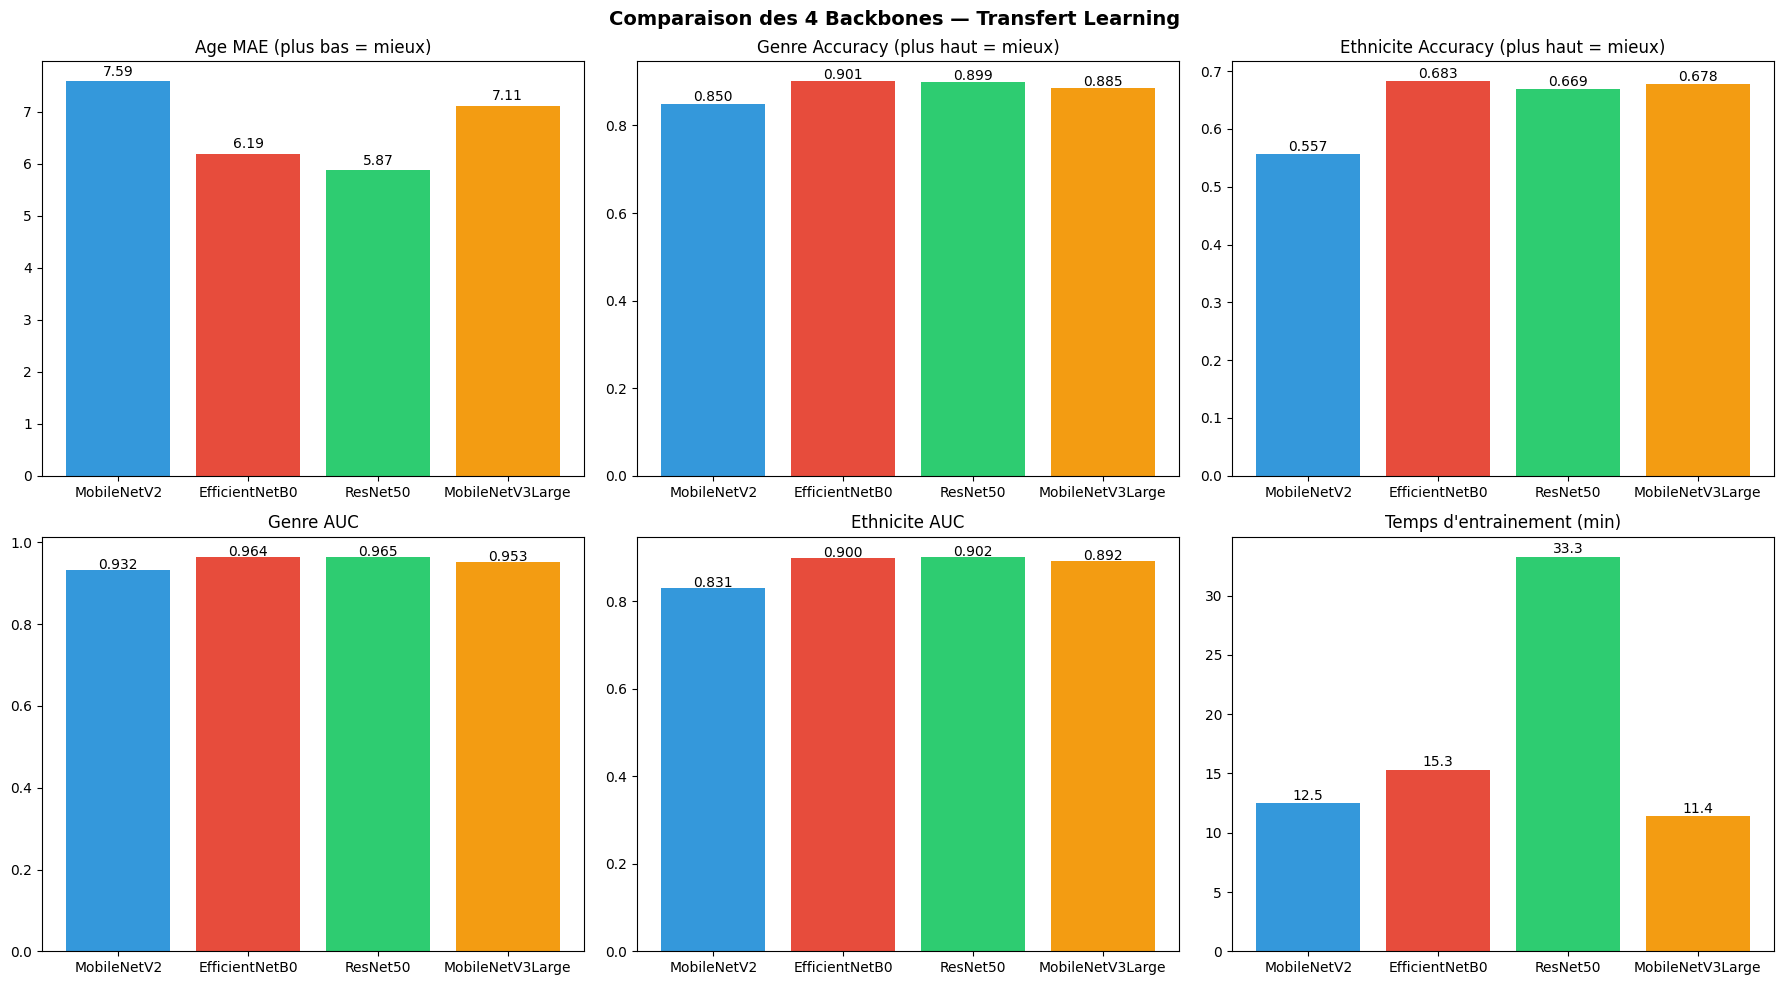

Graphique sauvegarde.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
names = list(all_results.keys())
colors = ["#3498DB", "#E74C3C", "#2ECC71", "#F39C12"]

vals = [all_results[n]["Age MAE"] for n in names]
axes[0, 0].bar(names, vals, color=colors)
axes[0, 0].set_title("Age MAE (plus bas = mieux)")
for i, v in enumerate(vals):
    axes[0, 0].text(i, v + 0.1, f"{v:.2f}", ha="center")

vals = [all_results[n]["Genre Accuracy"] for n in names]
axes[0, 1].bar(names, vals, color=colors)
axes[0, 1].set_title("Genre Accuracy (plus haut = mieux)")
for i, v in enumerate(vals):
    axes[0, 1].text(i, v + 0.005, f"{v:.3f}", ha="center")

vals = [all_results[n]["Eth Accuracy"] for n in names]
axes[0, 2].bar(names, vals, color=colors)
axes[0, 2].set_title("Ethnicite Accuracy (plus haut = mieux)")
for i, v in enumerate(vals):
    axes[0, 2].text(i, v + 0.005, f"{v:.3f}", ha="center")

vals = [all_results[n]["Genre AUC"] for n in names]
axes[1, 0].bar(names, vals, color=colors)
axes[1, 0].set_title("Genre AUC")
for i, v in enumerate(vals):
    axes[1, 0].text(i, v + 0.002, f"{v:.3f}", ha="center")

vals = [all_results[n]["Eth AUC"] for n in names]
axes[1, 1].bar(names, vals, color=colors)
axes[1, 1].set_title("Ethnicite AUC")
for i, v in enumerate(vals):
    axes[1, 1].text(i, v + 0.002, f"{v:.3f}", ha="center")

vals = [all_results[n]["Temps (min)"] for n in names]
axes[1, 2].bar(names, vals, color=colors)
axes[1, 2].set_title("Temps d'entrainement (min)")
for i, v in enumerate(vals):
    axes[1, 2].text(i, v + 0.3, f"{v:.1f}", ha="center")

plt.suptitle(
    "Comparaison des 4 Backbones — Transfert Learning", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparaison_backbones.png"), dpi=150)
plt.show()
print("Graphique sauvegarde.")

## 1.7 Determination du meilleur backbone

Score composite pondere **genre/ethnicite** (prioritaires) :


In [ ]:
# Score composite: Genre et Ethnicite peses x3, Age pese x1
scores = {}
for name, r in all_results.items():
    score = (
        r["Genre Accuracy"] * 3
        + r["Genre AUC"] * 2
        + r["Eth Accuracy"] * 3
        + r["Eth AUC"] * 2
        + max(0, 1 - r["Age MAE"] / 20) * 1  # normalise, poids faible
    )
    scores[name] = round(score, 4)
    print(f"  {name}: score = {scores[name]}")

best_backbone = max(scores, key=scores.get)
print(f"\n>>> MEILLEUR BACKBONE: {best_backbone} (score: {scores[best_backbone]})")

# Sauvegarder pour les notebooks suivants
import json

config = {
    "best_backbone": best_backbone,
    "scores": scores,
    "results": {
        k: {kk: float(vv) for kk, vv in v.items()} for k, v in all_results.items()
    },
}
with open(os.path.join(OUTPUT_DIR, "best_backbone.json"), "w") as f:
    json.dump(config, f, indent=2)
print(f"Config sauvegardee: {os.path.join(OUTPUT_DIR, 'best_backbone.json')}")

  MobileNetV2: score = 8.3693
  EfficientNetB0: score = 9.1715
  ResNet50: score = 9.146
  MobileNetV3Large: score = 9.0238

>>> MEILLEUR BACKBONE: EfficientNetB0 (score: 9.1715)
Config sauvegardee: /home/optimalako/Projet/SAE/training/output_v2/best_backbone.json


## Resume

Le meilleur backbone a ete determine. Executez maintenant :

1. `2_modele_multitache.ipynb` pour l'entrainement complet du modele multitache
2. `3_modeles_individuels.ipynb` pour les 3 modeles specialises
